# <em> Data Analysis, Dimensionality Reduction</em>


***

### Imports

In [1]:
import numpy as np
import scipy as sp
from scipy.integrate import quad
#For plotting
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline

***

#### Fitting Gaussian Contours to a 2D Data

Gaussian distribution function plays a central role in statistics and is the most ubiquitous distribution in physics. It often provides a good approximation to the true probability density function (pdf) even in cases where its application is not strictly correct. <br><br>
Suppose that we have measured 1000 pairs of values $(x_1, y_1), ... , (x_{1000}, y_{1000})$ of two variables $x, y$ and saved these measurements to a .dat file ("Part1_data.dat"). Plot their 1-dimensional pdf's and determine how well Gaussian pdf can approximate them. Compute the mean, variance, median, mode, 68% and 95% confidence intervals, and correlation coefficient.

<span style="color:blue"><i> Plot 1-dimensional pdf for $x$, i.e. plot a normalized histogram. Make a reasonable choice for bin size - say 40 bins? </i></span> <br>

In [69]:
# Load a given 2D data
data = np.loadtxt("./Part1_data.dat")
x = data[:,0]
y = data[:,1]

/var/folders/nr/rbr3ndbn343d7__44zxt3v780000gn/T/ipykernel_4469/3990512461.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis_r') # Get desired colormap


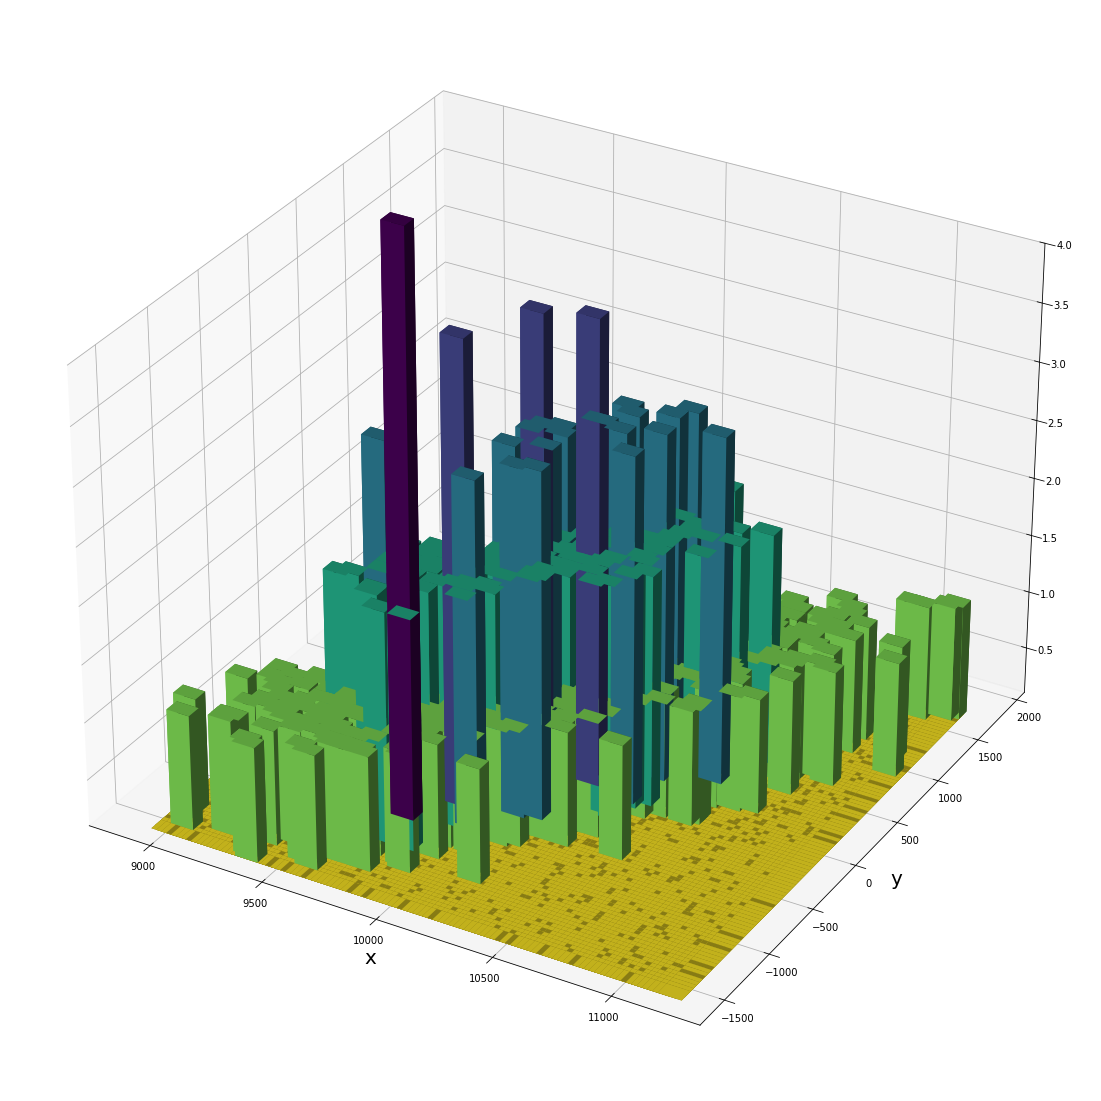

In [70]:
fig = plt.figure(figsize=[20,20])
ax = fig.add_subplot(projection='3d')

hist, xedges, yedges = np.histogram2d(x, y, bins=100)

xpos, ypos = np.meshgrid(xedges[:-1] + 0.999, yedges[:-1] + 0.999, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0

dx = dy = 100 * np.ones_like(zpos)
dz = hist.ravel()

cmap = cm.get_cmap('viridis_r') # Get desired colormap
max_height = np.max(hist)   # get range of colorbars so we can normalize
min_height = np.min(hist)

# scale each z to [0,1], and get their rgb values
rgba = [cmap((k-min_height)/max_height) for k in dz]

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average', color=rgba)
ax.axes.set_zlim3d(bottom=0.1, top=4)
plt.xlabel('x', fontsize=20)
plt.ylabel('y', fontsize=20)
plt.show()

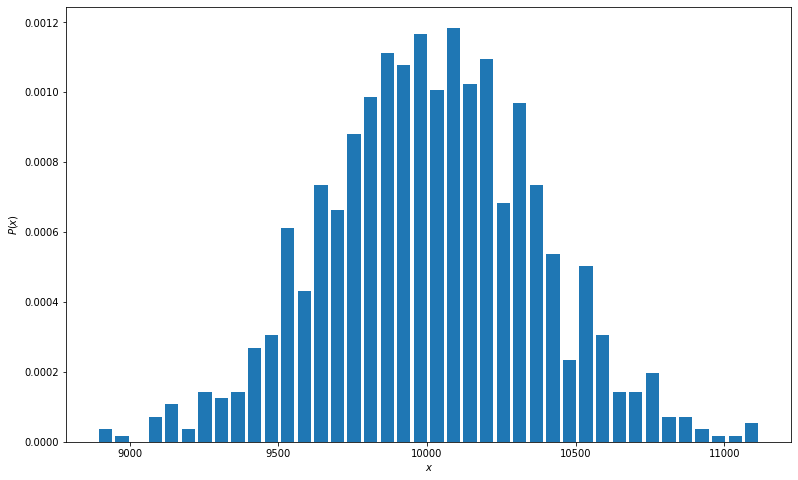

In [11]:
# Plot a normalized histogram (Hint - https://matplotlib.org/devdocs/api/_as_gen/matp
# Having 25 elements per each bin
N = len(x); n = int(N/25)
# Make plot
plt.figure(figsize=(13,8))
plt.hist(x, bins = n, histtype = 'bar', density=True, rwidth = 0.8) 
plt.xlabel('$x$')
plt.ylabel('$P(x)$')
plt.show()

<span style="color:blue"> <i> Calculate the mean, variance, and median of $x$. We first do it by hand, then we check using built-in functions from numpy. </i></span>

In [13]:
sig_figs = 4

# Calculating "by hand"
mean_x = sum(x)/len(x)
variance_x = sum([(i-mean_x)**2 for i in x])/len(x)

x.sort()
median_x = (x[int(len(x)/2) - 1] + x[int(len(x)/2)])/2

print("For x, mean = ", np.round(mean_x,sig_figs), ", variance = ", np.round(variance_x,sig_figs),
      ", and median = ", np.round(median_x,sig_figs))

# Using in-built functions from numpy
mean_x = np.mean(x)
variance_x = np.var(x)
median_x = np.median(x)

print("For x, mean = ", np.round(mean_x,sig_figs), ", variance = ", np.round(variance_x,sig_figs), 
      ", and median = ", np.round(median_x,sig_figs))

For x, mean =  10011.5939 , variance =  125445.6812 , and median =  10011.8167
For x, mean =  10011.5939 , variance =  125445.6812 , and median =  10011.8167


<span style="color:blue"> <i> Smoothly interpolate the discrete probability density found previously. Then, find the mode and symmetric 68%, 95% confidence intervals. (Suggestion - Read https://docs.scipy.org/doc/numpy/reference/generated/numpy.histogram.html and https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.UnivariateSpline.html)</i></span><br><br>
(Note - For 68% confidence interval, we can find the range where 68% of the given sample occurs. We assume that such interval is symmetrically placed around the mean. <br>
In other words, find $a$ such taht
$$ 0.68 = \int_{\mu-a}^{\mu+a} P(x) $$
where $P(x)$ is $x$'s pdf, and $\mu$ is the mean.<br>
One way to find $a$ is to define a cumulative distribution function (cdf) $G(x)$ and find $a$ such that $G(\mu+a)-G(\mu-a) = .68$.)

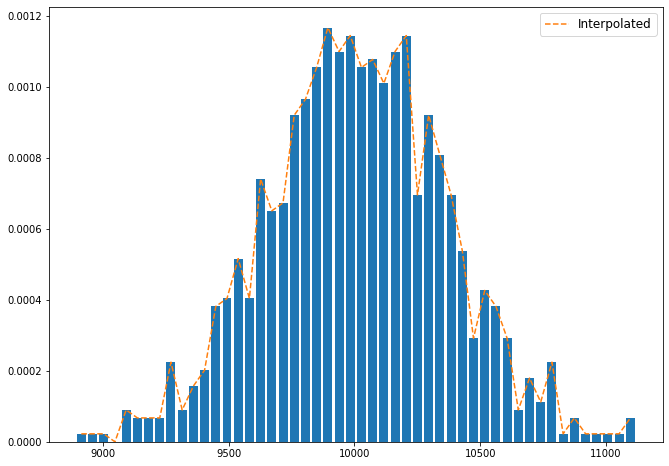

In [18]:
# NOTE: The following skeleton code is only a suggestion.
from scipy.interpolate import UnivariateSpline

n = 50
p, xvar = np.histogram( x,bins=n, density = True)

# Find x values at the center of each bin (call it xvar)
xvar = xvar[:-1] + (xvar[1] - xvar[0])/2

# Find the interpolated function f
f = UnivariateSpline(xvar, p, s=n) # n is number of bins
# Change the amount of smoothing
#f.set_smoothing_factor(1.e-8)
f.set_smoothing_factor(1.e-15)

# Plot both histogram and interpolated function
plt.figure(figsize=(11,8))
plt.hist(x, bins = n, density = True, rwidth = 0.8)
plt.plot(xvar,p, '--', label = "Interpolated")
plt.legend(fontsize=12)
plt.show()

For x, mode =  9894.180345896273


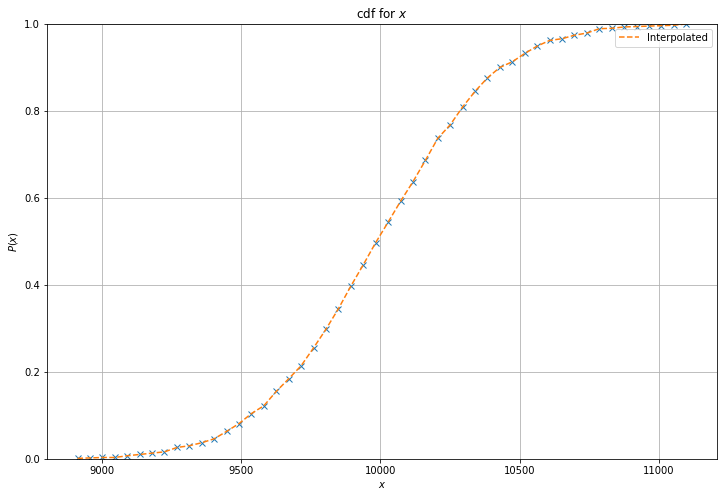

For x, 68% confidence interval is 10011.59392367306 ± 348.16200519519407 
(9663.431918477865, 10359.755928868253)
and 95% interval is 10011.59392367306 ± 723.7732020512503 
(9287.820721621809, 10735.36712572431)


In [37]:
# Find the mode
mode2_x = xvar[list(p).index(max(p))]
# or mode using argmax
mode2_x = xvar[np.argmax(f(xvar))]
print("For x, mode = ", mode_x)

# Define the cdf
p, xvar = np.histogram(x, bins = n, density=True) 
delta_xvar = (xvar[1] - xvar[0])
cdf = p*delta_xvar
for i in range(len(cdf))[1:]:
    cdf[i] = cdf[i-1] + cdf[i]
xvar = xvar[:-1] + (xvar[1] - xvar[0])/2

# Interpolation
cdf_interpolated = UnivariateSpline(xvar, cdf, s=n) 
cdf_interpolated.set_smoothing_factor(0)

# Plot the cdf
plt.figure(figsize=(12,8))
plt.plot(xvar, cdf, 'x')
plt.plot(xvar, cdf_interpolated(xvar), '--', label = "Interpolated") 
plt.ylim(0, 1)
plt.xlabel('$x$')
plt.ylabel('$P(x)$')
plt.title('cdf for $x$')
plt.legend()
plt.grid()
plt.show()

# function which computes the confidence intervals
def findinterval(f, percentage): 
    delta_x = np.sqrt(variance_x)/2000
    testx = np.append(np.arange(mean_x-3*np.sqrt(variance_x), mean_x, delta_x), 
                      np.arange(mean_x, mean_x + 3*np.sqrt(variance_x), delta_x)
                     )               
    ind = int(len(testx)/2)              
    for i in range(int(len(testx)/2)):
        if cdf_interpolated(testx[ind+i])-cdf_interpolated(testx[ind-i]) > percentage:
            val = testx[ind+i] - testx[ind]
            return val
CI_68 = findinterval(cdf_interpolated, .68)
CI_95 = findinterval(cdf_interpolated, .95)
                      
print("For x, 68% confidence interval is", mean_x, "±", CI_68,
      f'\n{mean_x-CI_68, mean_x+CI_68}'
      "\nand 95% interval is", mean_x, "±", CI_95, 
      f'\n{mean_x-CI_95, mean_x+CI_95}')


Assuming that the distribution is Gaussian, 68% and 95% confidence interval corresponds to $\mu \pm 1\sigma$ and $\mu \pm 2\sigma$.  </i></span>

In [39]:
print("Assuming Gaussian distribution, 68% confidence interval is", mean_x, "±", np.sqrt(variance_x),
     ", and 95% interval is", mean_x, "±", 2*np.sqrt(variance_x))

Assuming Gaussian distribution, 68% confidence interval is 10011.59392367306 ± 354.18311820368945 , and 95% interval is 10011.59392367306 ± 708.3662364073789


You should find that the Gaussian distribution is a reasonable approximation in this case.

<span style="color:blue"> <i> Plot a Gaussian distribution with the mean and variance from above, on top of the probability density histogram plotted initially. </i></span>

In [40]:
# Define Gaussian distribution
def gaussian(x, mu, sigma):
    return ((1 / (np.sqrt(2 * np.pi) * sigma)) *np.exp(-0.5 * (1 / sigma * (x - mu))**2))

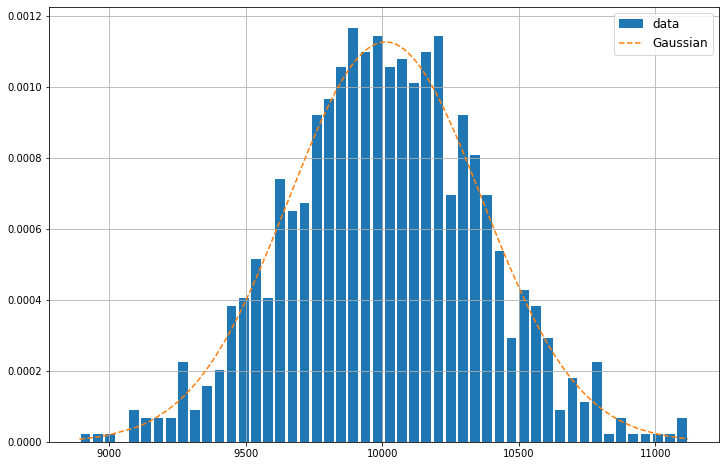

In [46]:
# Plot histogram
plt.figure(figsize=(12, 8))
plt.hist(x, bins = 50, density = True, rwidth = 0.8, label='data')

# Plot Gaussian distribution on top
mu,sig = (mean_x,np.sqrt(variance_x))
plt.plot(x,gaussian(x,mu,sig), '--', label = "Gaussian")
plt.legend(fontsize=12)
plt.grid()


<span style="color:blue"> <i> Repeat everything for $y$ data.  </i></span>

For y, mean =  25.825405595652857 , variance =  339007.3051560137 , and median =  32.16872896054926


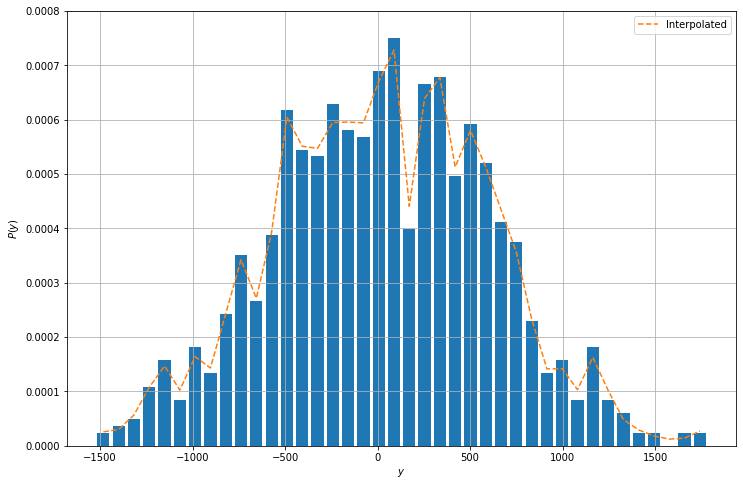

For y, mode =  88.59920802783427


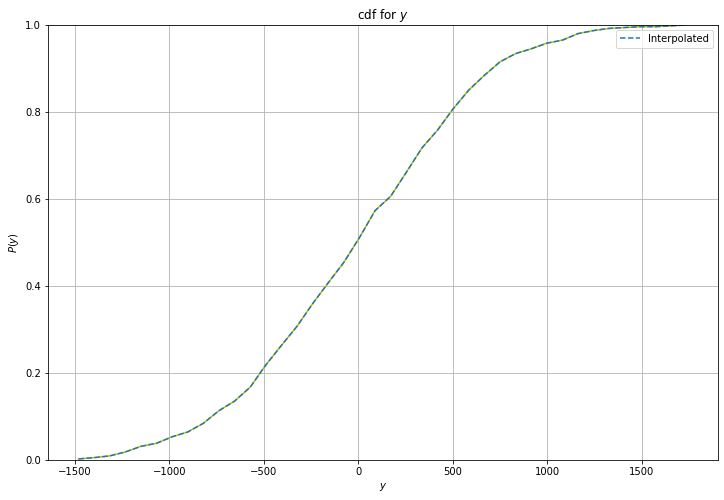

For y, 68% confidence interval is 25.825405595652857 ± 578.1676350694327 
(-552.3422294737798, 10589.761558742492)
and 95% interval is 10011.59392367306 ± 1158.6642434926193 
(-1132.8388378969664, 11170.258167165679)


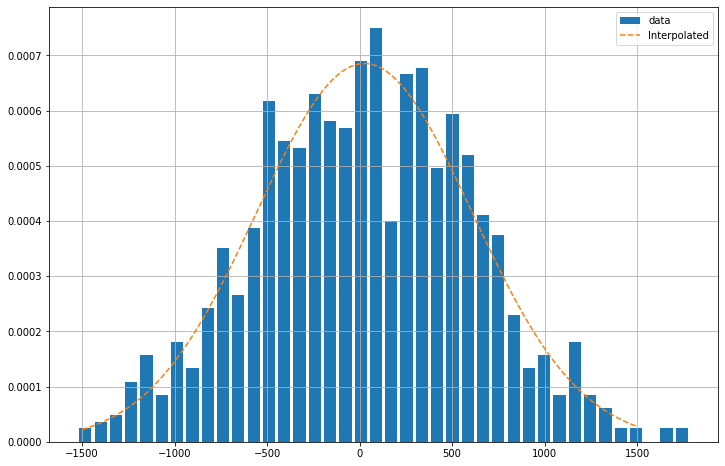

In [53]:
N = len(y) 
n = int(N/25)

# Calculating "by hand"
mean_y = sum(y)/len(y)
variance_y = sum((y-mean_y)**2)/len(y)
y_sorted = sorted(y) 

if len(y)%2 == 0:
    median_y = (y_sorted[int( (len(y)/2)-1 )] + y_sorted[int( (len(y)/2) )])/2. 
else:
    median_y = y_sorted[int( np.floor(len(y)/2) )]
    
print("For y, mean = ", mean_y, ", variance = ", variance_y, ", and median = ", median_y)

p, yvar = np.histogram(y, bins = n, density = True)
# Find y values at the center of each bin
yvar = yvar[:-1] + (yvar[1] - yvar[0])/2

# Find the interpolated function f
f = UnivariateSpline(yvar, p, s=n) 

# Change the amount of smoothing 
f.set_smoothing_factor(1.e-8)

# Plot both histogram and interpolated function
plt.figure(figsize=(12,8))
plt.hist(y, bins = n, histtype = 'bar', density = True, rwidth = 0.8) 
plt.plot(yvar, f(yvar), '--', label = "Interpolated")
plt.ylim(0, 0.0008)
plt.legend()
plt.xlabel('$y$') 
plt.ylabel('$P(y)$') 
plt.grid()
plt.show()

# Find the mode
mode_y = yvar[np.argmax(f(yvar))] 
print("For y, mode = ", mode_y)

# Find 68% and 95% confidence intervals

# Define the cdf
p, yvar = np.histogram(y, bins = n, density = True) 
delta_yvar = (yvar[1] - yvar[0])
cdf = p*delta_yvar
for i in range(len(cdf))[1:]:
    cdf[i] = cdf[i-1] + cdf[i]
yvar = yvar[:-1] + (yvar[1] - yvar[0])/2

# Interpolation
cdf_interpolated = UnivariateSpline(yvar, cdf, s=n) 
cdf_interpolated.set_smoothing_factor(0)

# Plot the cdf
plt.figure(figsize=(12,8))
plt.plot(yvar, cdf, 'y')
plt.plot(yvar, cdf_interpolated(yvar), '--', label = "Interpolated") 
plt.ylim(0, 1)
plt.xlabel('$y$')
plt.ylabel('$P(y)$')
plt.title('cdf for $y$')
plt.legend()
plt.grid()
plt.show()

def findinterval(f, percentage): 
    delta_y = np.sqrt(variance_y)/2000
    
    testy = np.append(
        np.arange(mean_y - 3*np.sqrt(variance_y), mean_y, delta_y),
        np.arange(mean_y, mean_y + 3*np.sqrt(variance_y), delta_y)
    )
                      
    ind = int(len(testy)/2)
                      
    for i in range(int(len(testy)/2)):
        if f(testy[ind+i]) - f(testy[ind-i]) > percentage:
            val = testy[ind+i] - testy[ind]
            return val

CI_68 = findinterval(cdf_interpolated, .68)
CI_95 = findinterval(cdf_interpolated, .95)
                      
print("For y, 68% confidence interval is", mean_y, "±", CI_68,
      f'\n{mean_y-CI_68, mean_x+CI_68}'
      "\nand 95% interval is", mean_x, "±", CI_95, 
      f'\n{mean_y-CI_95, mean_x+CI_95}')

# Plot histogram
plt.figure(figsize=(12,8))
plt.hist(y, bins = n, histtype = 'bar', density = True, rwidth = 0.8, label = 'data') # Plot Gaussian
y_gaussian = np.linspace(-1500, 1500, 1000)
plt.plot(y_gaussian, gaussian(y_gaussian, mean_y, np.sqrt(variance_y)), '--', label = 'Interpolated')
plt.legend()
plt.grid()
plt.show()

<span style="color:blue"> <i> First, compute the covariance ($C_{xy}$) of $x$ and $y$ as well as the correlation coefficient $\rho = \frac{C_{xy}}{\sigma_{x}\sigma_{y}}$. Then, make a 2-d scatter plot of the dataset with few Gaussian contours (ellipses). </i></span>

In [55]:
def bivariate_normal(X, Y, sigmax=1.0, sigmay=1.0, mux=0.0, muy=0.0, sigmaxy=0.0):

    """
    Bivariate Gaussian distribution for equal shape *X*, *Y*.
    See `bivariate normal
    <http://mathworld.wolfram.com/BivariateNormalDistribution.html>`_
    at mathworld.
    """
    Xmu = X-mux
    Ymu = Y-muy

    rho = sigmaxy/(sigmax*sigmay)
    z = Xmu**2/sigmax**2 + Ymu**2/sigmay**2 - 2*rho*Xmu*Ymu/(sigmax*sigmay)
    denom = 2*np.pi*sigmax*sigmay*np.sqrt(1-rho**2)
    return np.exp(-z/(2*(1-rho**2))) / denom

The covariance between x and y is 166453.76011931218
The correlation coefficient of x and y is 0.8071629606146947


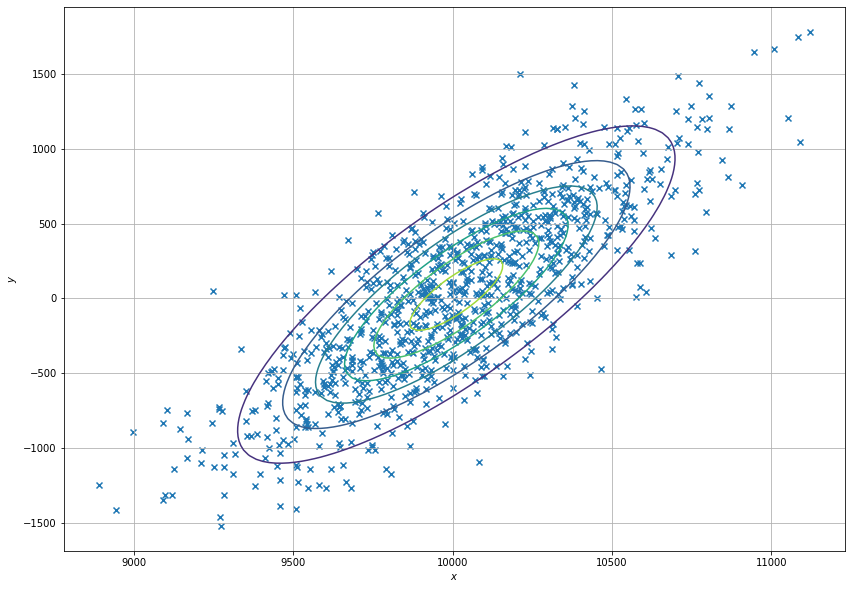

In [59]:
# Compute the covariance and correlation coefficient
data = np.loadtxt("./Part1_data.dat")
x = data[:,0]
y = data[:,1]

cov = sum([(i-mean_x)*(j-mean_y) for (i,j) in zip(x,y)])/((len(x)))
corrCof = cov/(np.sqrt(variance_x)*np.sqrt(variance_y))
print("The covariance between x and y is", cov)

print("The correlation coefficient of x and y is", corrCof)

# Make a 2-d scatter plot with Gaussian contours

import matplotlib.mlab as mlab

# Create coordinate matrices from coordinate vectors.
gridx = np.linspace(9000, 11000, 100)
gridy = np.linspace(-1500, 1500, 100)
X, Y = np.meshgrid(gridx, gridy)

# Create bivariate Gaussian distribution for equal shape X, Y (https://matplotlib.org/api/mlab_api.html)
Z = bivariate_normal(X, Y, np.sqrt(variance_x), np.sqrt(variance_y), mean_x, mean_y, cov)

# Make plot
plt.figure(figsize = (14, 10))
# Scatter plot
plt.scatter(x, y, marker = 'x')
# Gaussian contour plots
plt.contour(X, Y, Z)

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid()
plt.show()


The above contour plot is a bird eye view of the 3-d mesh plot; these are ellipses of equal probability. The coloring represents the intensity. Yellow central ellipse is the region of highest probability; the peak of 2-d Gaussian distribution is at the center of this ellipse. As we move away from the peak, the probability lowers.

***

#### Central Limit Theorem

Plot the binomial distribution $P(N_A, N)$ for different values of $N$ and plot the Gaussian with mean and variance for the binomial. Similarly, plot the Poisson distribution with the mean varying from 1 to 10. See if both binomial and Poisson approach Gaussian as the mean/$N$ increases.<br><br>
(Reference - Kardar p. 41) For the binomial distribution, consider a random variable with two outcomes $A$ and $B$ of relative probabilities $p_A$ and $p_B = 1 - p_A$. The probability that in $N$ trials the event $A$ occurs exactly $N_A$ times is given by the binomial distribution:
  
$$ p_N(N_A) = \binom{N}{N_A} p_A^{N_A}(1-p_A)^{N-N_A}. $$
<br>
<span style="color:blue"> <i> Plot the binomial distribution $P(N_A, N)$ for $N = 5, 20, 40, 100, 300$. In the same figure, plot the Gaussian with mean and variance for the binomial and see how similar they get as you increase $N$. Let $p_A = 0.5$ and $0.1$.  </i></span>

In [63]:
# Import packages for the bionomial coefficient
from scipy.special import binom

# Define the probability for the binomial distribution
def pdf_binom(p_A, N, N_A):

    p_BN = (1-p_A)**(N-N_A)
    p_AN = p_A**N_A

    return binom(N, N_A)*p_AN*p_BN

# Define Gaussian distribution
def gaussian(x, mu, sigma):
    return ((1 / (np.sqrt(2 * np.pi) * sigma)) *np.exp(-0.5 * (1 / sigma * (x - mu))**2))

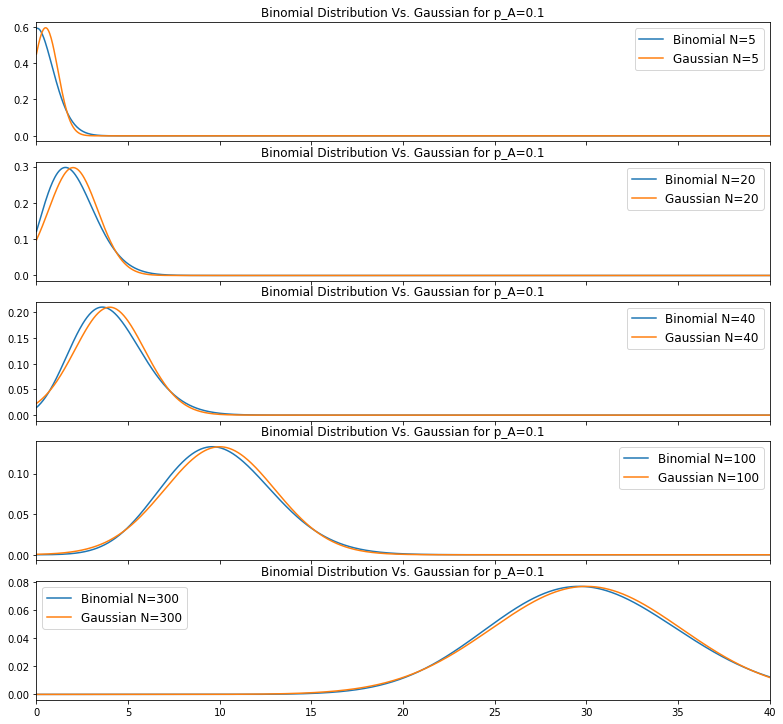

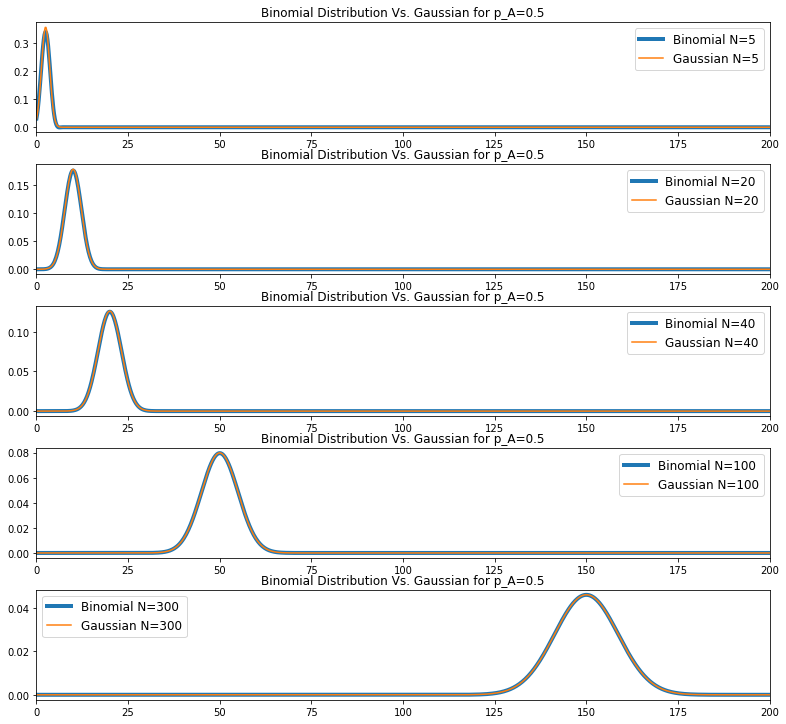

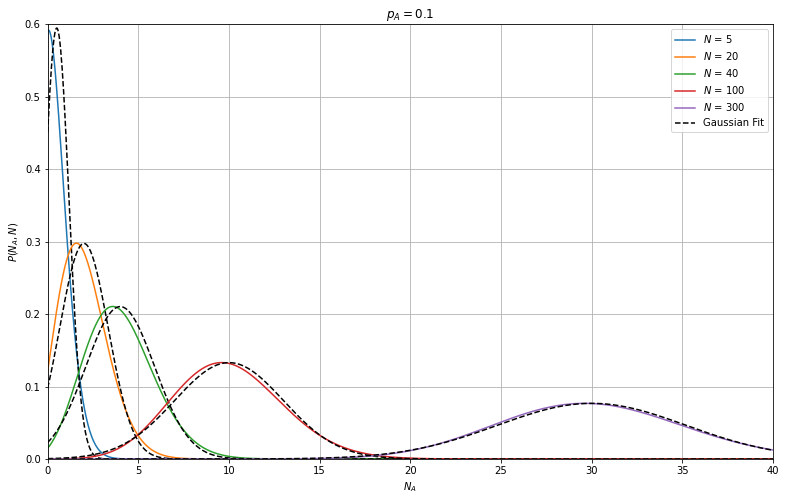

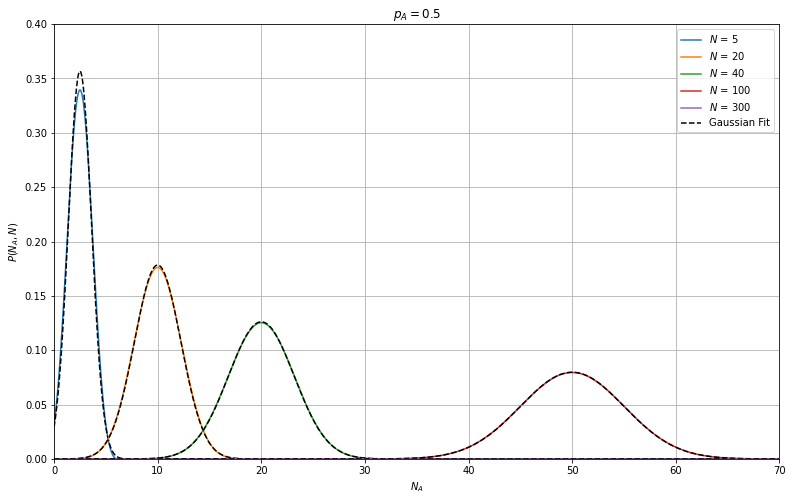

In [67]:
import numpy as np
N = [5, 20, 40, 100, 300]

# Make plot

# For p_A = 0.1
N_A = np.linspace(0, 40, 1000)
p_A = 0.1

fig, ax = plt.subplots(nrows=len(N), ncols=1, figsize=(11, 10), sharex=True)
fig.tight_layout()
plt.xlim(0,40)

for i,n in enumerate(N):
    ax[i].set_title(f'Binomial Distribution Vs. Gaussian for p_A={p_A}')
    ax[i].plot(N_A, pdf_binom(p_A, n, N_A), label=f'Binomial N={n}')
    mu, sigma = (p_A*n, np.sqrt(n*p_A*(1-p_A)))
    ax[i].plot(N_A,gaussian(N_A, mu, sigma), label=f'Gaussian N={n}')
    ax[i].legend(fontsize=12)

plt.show()

# For p_A = 0.5
N_A = np.linspace(0, 200, 1000)
p_A = 0.5

fig, ax = plt.subplots(nrows=len(N), ncols=1, figsize=(11, 10), sharex=False)
fig.tight_layout()

for i,n in enumerate(N):
    ax[i].set_title(f'Binomial Distribution Vs. Gaussian for p_A={p_A}')
    ax[i].plot(N_A, pdf_binom(p_A, n, N_A), linewidth=4, label=f'Binomial N={n}')
    mu, sigma = (p_A*n, np.sqrt(n*p_A*(1-p_A)))
    ax[i].plot(N_A,gaussian(N_A, mu, sigma), label=f'Gaussian N={n}')
    ax[i].legend(fontsize=12)
    ax[i].set_xlim(0,200)

plt.show()

N = [5, 20, 40, 100, 300]
N_A = np.linspace(0, 40, 1000)
# Make plot
plt.figure(figsize= (13, 8))
# For p_A = 0.1
p_A = 0.1
for i in range(len(N)):
    plt.plot(N_A, pdf_binom(p_A, N[i], N_A), label = '$N$ = %d' %N[i]) 
    if i == len(N)-1:
        plt.plot(N_A, gaussian(N_A, N[i]*p_A, np.sqrt(N[i]*p_A*(1-p_A))), 'k--', label='Gaussian Fit') 
    else:
        plt.plot(N_A, gaussian(N_A, N[i]*p_A, np.sqrt(N[i]*p_A*(1-p_A))), 'k--') 
        
plt.xlim(0, 40)
plt.ylim(0, 0.6) 
plt.xlabel('$N_A$') 
plt.ylabel('$P(N_A, N)$') 
plt.legend() 
plt.title('$p_A = 0.1$')
plt.grid()
plt.show()


N_A = np.linspace(0, 70, 1000) 
plt.figure(figsize= (13, 8))
# For p_A = 0.5
p_A = 0.5
for i in range(len(N)):
    plt.plot(N_A, pdf_binom(p_A, N[i], N_A), label = '$N$ = %d' %N[i]) 
    if i == len(N)-1:
        plt.plot(N_A, gaussian(N_A, N[i]*p_A, np.sqrt(N[i]*p_A*(1-p_A))), 'k--', label='Gaussian Fit')
    else:
        plt.plot(N_A, gaussian(N_A, N[i]*p_A, np.sqrt(N[i]*p_A*(1-p_A))), 'k--') 

plt.xlim(0, 70)        
plt.ylim(0, 0.4) 
plt.xlabel('$N_A$') 
plt.ylabel('$P(N_A, N)$') 
plt.legend() 
plt.title('$p_A = 0.5$') 
plt.grid()
plt.show()

In class, we find that the binomial distribution is approximately normal (with mean $Np_A$ and variance $Np_A(1-p_A)$) as $N \rightarrow \infty$, by the central limit theorem. The proof of this theorem can be carried out using Stirling's approximation:
  
$$ N! \approx N^N e^{-N}\sqrt{2\pi N} $$
<br>
<span style="color:blue"><i> Plot the above Stirling's formula approximation (i.e. Compare $N!$ with Stirling's approximation. Compute the residual: (actual-estimate)/actual.) </i></span><br>
(Note: $\Gamma(n+1) = n!$)


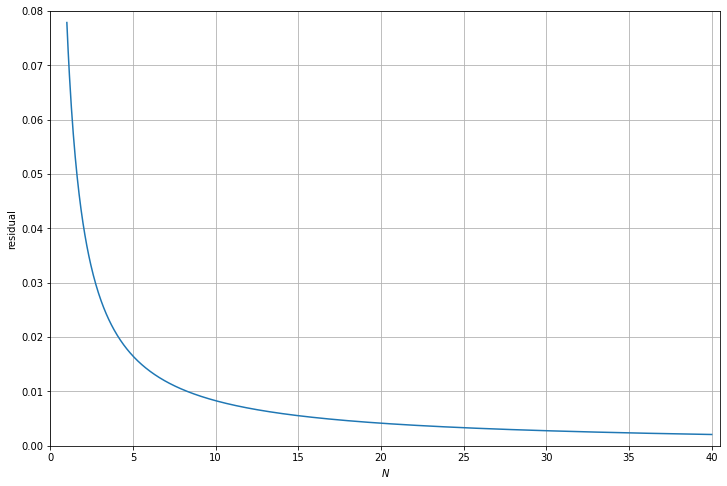

In [78]:
from scipy.special import gamma

Nvals = np.linspace(1, 40, 1000)

actual = gamma(Nvals+1)
estimate = np.array([(n**n)*np.exp(-n)*np.sqrt(2*np.pi*n) for n in Nvals])

plt.figure(figsize=(12,8))
plt.plot(Nvals, (actual-estimate)/actual)
plt.xlabel('$N$')
plt.ylabel('residual')
plt.xlim(0,40.5)
plt.ylim(0,0.08)
plt.grid()
plt.show()

We find that residual $\rightarrow 0$ as $N \rightarrow \infty$.

Next, consider the Poisson distribution (Kardar p. 42):
$$ P(\lambda) = \frac{\lambda^k e^{-\lambda}}{k!} $$
where $k$ is the number of occurrences. Its mean and variance are $\lambda$.<br><br>
<span style="color:blue"> <i> Plot $P(\lambda)$ as a function of $k$ for $\lambda = 1, 3, 5, 10, 20$. In the same figure, plot the Gaussian with mean and variance for the Poisson and see how similar they get. </i></span><br>

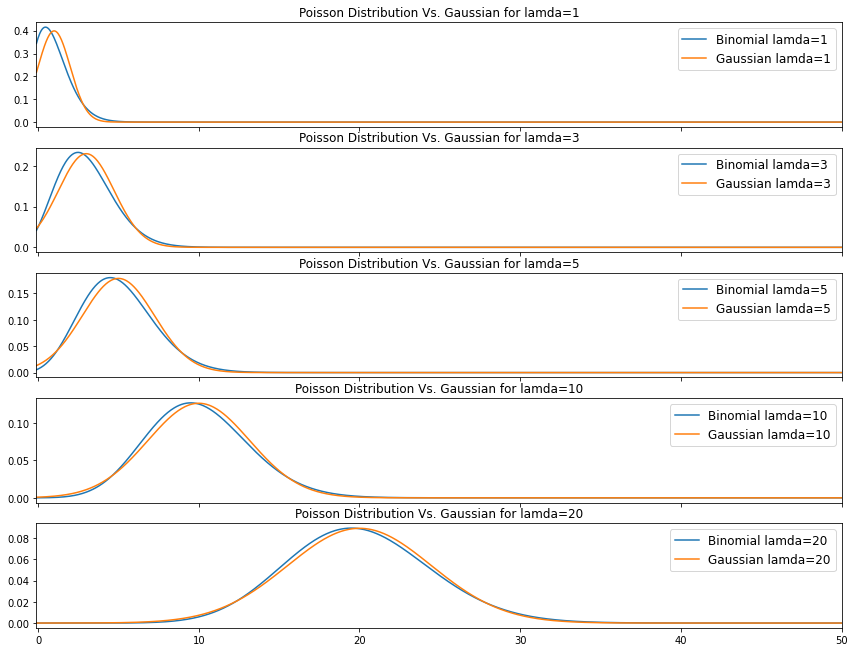

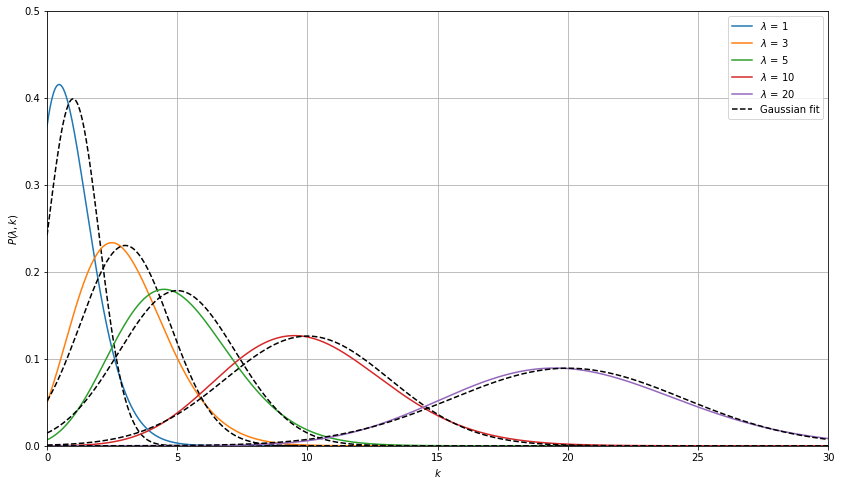

In [84]:
# Define the Poisson distribution
def Poisson(L,k):
    return ((L**k)*np.exp(-L))/gamma(k+1)

L = [1,3,5,10,20]
k =  np.linspace(-0.1, 50, 1000)
# Make plot
fig, ax = plt.subplots(nrows=len(L), ncols=1, figsize=(12, 9), sharex=True)
fig.tight_layout()
plt.xlim(-0.1,50)

for i,l in enumerate(L):
    ax[i].set_title(f'Poisson Distribution Vs. Gaussian for lamda={l}')
    ax[i].plot(k, Poisson(l,k), label=f'Binomial lamda={l}')
    mu, sigma = (l,np.sqrt(l))
    ax[i].plot(k,gaussian(k, mu, sigma), label=f'Gaussian lamda={l}')
    ax[i].legend(fontsize=12)
    
# Define the Poisson distribution
def poisson(L, k):
    return (L**k)*np.exp(-L)/(gamma(k+1))

L = [1, 3, 5, 10, 20]
k = np.linspace(0, 30, 1000)

# Make plot
plt.figure(figsize= (14, 8))
for i in range(len(L)):
    plt.plot(k, poisson(L[i], k), label = '$\lambda$ = %d' %L[i]) 
    if i == len(L)-1:
        plt.plot(k, gaussian(k, L[i], np.sqrt(L[i])), 'k--', label = 'Gaussian fit') 
    else:
        plt.plot(k, gaussian(k, L[i], np.sqrt(L[i])), 'k--') 

plt.xlim(0, 30)
plt.ylim(0, 0.5) 
plt.xlabel('$k$') 
plt.ylabel('$P(\lambda, k)$') 
plt.legend()
plt.grid()
plt.show()

<span style="color:blue"> <i> What happens as the mean/$N$ increases? </i></span><br>

As the mean/N increases, both Binomial and Poisson distributions start to align and become approximately normal.

***

#### Fitting Data to a Straight Line (Linear Regression)

(Reference - NR 15.2) We fit a set of 50 data points $(x_i, y_i)$ to a straight-line model $y(x) = a + bx$. The uncertainty $\sigma_i$ associated with each measurement $y_i$ is known, and we assume that the $x_i$'s are known exactly. To measure how well the model agrees with the data, we use the chi-square merti function: <br>
$$ \chi^2(a,b) = \sum_{i=0}^{N-1} \big( \frac{y_i-a-bx_i}{\sigma_i} \big)^2. $$
<br>
Make a scatter plot of data (including uncertainties) and find the best-fit line. Compute the errors on the two parameters $a$ and $b$ and plot lines where the two are changed by $\pm 1\sigma$.

<br>
<span style="color:blue"> <i> Plot data with error bars. (reference - https://matplotlib.org/api/_as_gen/matplotlib.axes.Axes.errorbar.html) </i></span><br>

In [85]:
# Load a given 2D data
data = np.loadtxt("./Part3_data.dat")
x = data[:,0]
y = data[:,1]
sig_y = data[:,2]

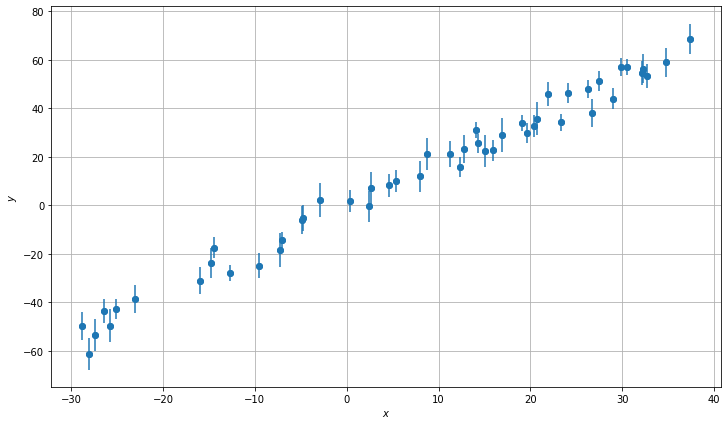

In [87]:
# Make plot
plt.figure(figsize = (12, 7))
# Scatter plot
plt.scatter(x,y)
plt.errorbar(x, y, yerr=sig_y, fmt="o")
plt.xlabel('$x$') 
plt.ylabel('$y$')
plt.grid()
plt.show()

(NR p. 781) We should minimize the above chi-square function to determine $a$ and $b$. At its minimum, derivatives of $\chi^2$ with respect to $a, b$ vanish:
  
$$ \frac{\partial{\chi^2}}{\partial{a}} = -2 \sum \frac{y_i - a - bx_i}{\sigma_i^2} = 0 \ \ \ \ \ \ \ \ \ \ \ \ (1) $$
$$ \frac{\partial{\chi^2}}{\partial{b}} = -2 \sum \frac{x_i(y_i - a - bx_i)}{\sigma_i^2} = 0   \ \ \ \ \ \ \ \ \ (2) $$
  
<br>
These conditions can be rewritten in a convenient form if we define the following sums:
  
$$ S = \sum \frac{1}{\sigma_i^2},\ S_x = \sum \frac{x_i}{\sigma_i^2},\ S_y = \sum \frac{y_i}
{\sigma_i^2} $$
$$ S_{xx} = \sum \frac{x_i^2}{\sigma_i^2},\ S_{xy} = \sum \frac{x_iy_i}{\sigma_i^2} $$
  
<br> With these, we can rewrite (1), (2) as:
$$ a*S + b*S_x = S_y $$
$$ a*S_x + b*S_{xx} = S_{xy} $$
<br> The solution to these is calculated as:
  
$$ \Delta = SS_{xx} - (S_x)^2 $$ <br>
$$ a = \frac{S_{xx}S_y - S_xS_{xy}}{\Delta} $$
$$ b = \frac{SS_{xy} - S_xS_y}{\Delta} $$
  
<br><span style="color:blue"><i> Find parameters $a, b$ which minimize the chi-square function and plot the best-fit line on top of the data. </i></span><br>

In [89]:
S = sum([1/(sig)**2 for sig in sig_y])
Sx_list = [i/(sig)**2 for (i,sig) in zip(x,sig_y)]
Sx = sum(Sx_list)
Sy = sum([i/(sig)**2 for (i,sig) in zip(y,sig_y)])
Sxx = sum([(i/sig)**2 for (i,sig) in zip(x,sig_y)])
Sxy = sum([sx*i for (sx,i) in zip(Sx_list,y)])
Delta = S*Sxx - (Sx**2)

In [93]:
a = (Sxx*Sy-Sx*Sxy)/Delta
b = (S*Sxy-Sx*Sy)/Delta

xx = np.linspace(-35, 45, 100)

def best_fit(x,a,b):
    return a + b*x

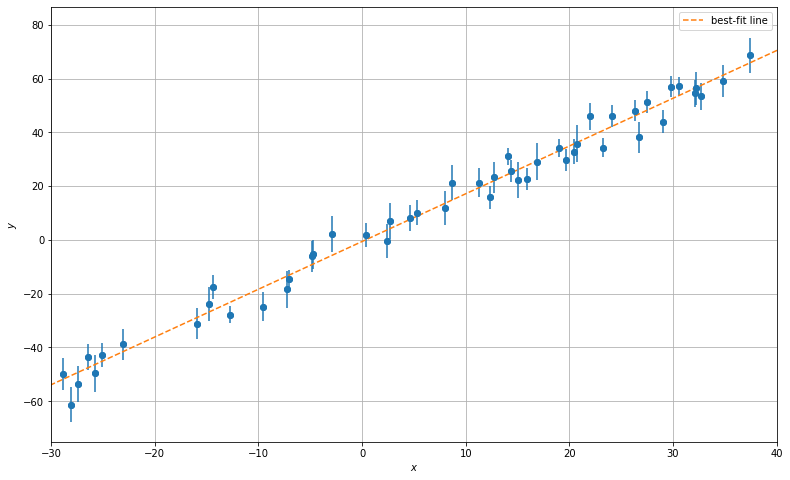

In [96]:
# Make plot
plt.figure(figsize = (13, 8))
plt.scatter(x,y)
plt.errorbar(x, y, yerr=sig_y, fmt="o")
plt.plot(xx, best_fit(xx, a, b), '--', label = 'best-fit line')

plt.grid()
plt.legend()
plt.xlim(-30, 40)
plt.xlabel('$x$') 
plt.ylabel('$y$')
plt.show()

Now, we must estimate the probable uncertainties in the estimates of $a$ and $b$, since obviously the measurement errors in the data must introduce some uncertainty in the determination of those parameters. If the data are independent, then each contributes its own bit of uncertainty to the parameters. Consideration of propagation of errors show that the variance $\sigma_f^2$ in the value of any function will be
  
$$ \sigma_f^2 = \sum \sigma_i^2 (\frac{\partial f}{\partial y_i})^2 $$  
  
<br> For the straight line, the derivatives of $a$ and $b$ with respect to $y_i$ can be directly evaluated from teh solution:  
  
$$ \frac{\partial a}{\partial y_i} = \frac{S_{xx}-S_x x_i}{\sigma_i^2 \Delta} $$
$$ \frac{\partial b}{\partial y_i} = \frac{S x_i-S_x}{\sigma_i^2 \Delta} $$
<br> Summing over the points, we get
$$ \sigma_a^2 = S_{xx}/\Delta $$
$$ \sigma_b^2 = S/\Delta $$
  
    
<span style="color:blue"> <i> Compute the errors ($\sigma_a, \sigma_b$) on the two parameters $a, b$ and plot lines where the two are changed by $\pm 1\sigma$.</i></span><br>
(Hint - Plot the 1$\sigma$ confidece band as in http://astropython.blogspot.com/2011/12/. We can use plt.fill_between to shade the region between plots.)

In [97]:
# Calculate sigma_a, sigma_b

sigma_a = np.sqrt(Sxx/Delta)
sigma_b = np.sqrt(S/Delta)

print('We estimate that a =', a ,"±", sigma_a, "and b =", b, "±", sigma_b)

We estimate that a = -0.595230946639397 ± 0.7528657804413229 and b = 1.7746965875529703 ± 0.036240121236055294


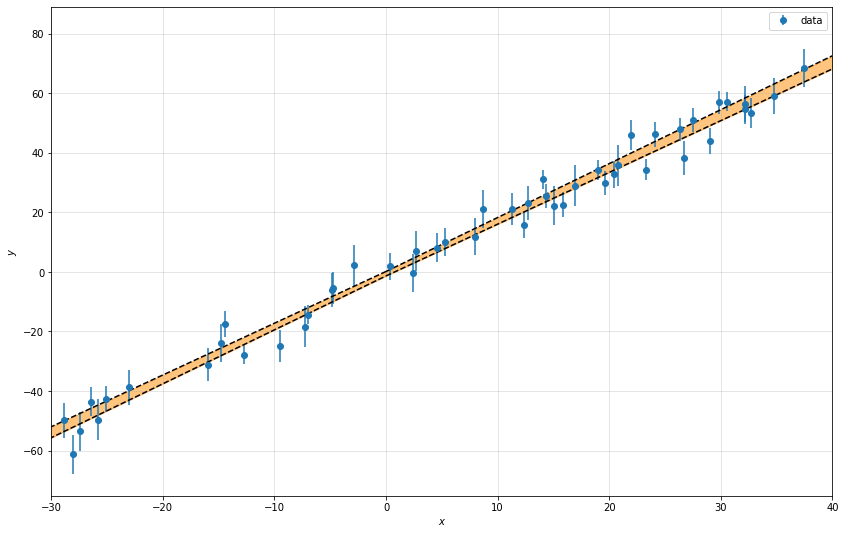

In [109]:
plt.figure(figsize = (14, 9))
plt.errorbar(x, y, yerr = sig_y, fmt='o', label = 'data')

xx1 = np.linspace(-35, 0, 100)
y_fit1 = (a+sigma_a) + (b-sigma_b)*xx1 
y_fit2 = (a-sigma_a) + (b+sigma_b)*xx1

xx2 = np.linspace(0, 45, 100)
y_fit3 = (a+sigma_a) + (b+sigma_b)*xx2 
y_fit4 = (a-sigma_a) + (b-sigma_b)*xx2

plt.plot(xx1, y_fit1, 'k--')
plt.plot(xx1, y_fit2, 'k--')
plt.plot(xx2, y_fit3, 'k--')
plt.plot(xx2, y_fit4, 'k--')

plt.fill_between(xx1, y_fit1, y_fit2, color='darkorange', alpha=0.5) 
plt.fill_between(xx2, y_fit3, y_fit4, color='darkorange', alpha=0.5)
plt.xlabel('$x$') 
plt.ylabel('$y$') 
plt.xlim(-30, 40) 
plt.legend() 
plt.grid(alpha=0.4)
plt.show()

***

#### Introduction to Supervised Learning

This task can serve as an introduction to machine learning, and it will use 1-D data fitting as an example. The power of machine learning is far greater than seen here, but for this example, no special machine learning packages are required, and we will write all of our required code.

The general goal of a supervised learning problem is to develop a model that can predict a label $y \in \mathcal{Y}$ from an input $x \in \mathcal{X}$ using existing sets of data $\{x_i, y_i\}_{i=1,...,n}$. When $\mathcal{Y}$ is discrete, this is called a classification problem, and when $\mathcal{Y}$ is continuous, this is called a regression problem.

We will use the very simple example of one-dimensional, real input and output, equivalently: $\mathcal{X}=\mathcal{Y}=\mathbb{R}$.

The model that is developed is called a *neural network*. The neural network is in general a flexible function $f_\phi: \mathcal{X} \rightarrow \mathcal{Y}$ which has internal parameters $\phi$. These parameters $\phi$ are *trained* in order to best predict the labels $y$ from the input $x$. In general, this network can be extremely complicated, especially when the input data is high-dimensional and/or has meaningful structure, but for this case, our neural network will just be a polynomial function of order $m$, and the model parameters $\phi$ are the coefficients:

$$f_\phi(x) = \phi_0 + \phi_1 x + \phi_2 x^2 + ... + \phi_m x^m.$$

<span style="color:blue"> <i> Write this general neural network function that takes in vectors $\phi$ and $x$. Make sure that this can be evaluated on a vector of x values, giving a vector of the same size. </i></span><br>


In [113]:
# Make a neural network function
def _poly(phi, x):
    '''
    The core model of the neural network. Evaluates a polynomial with coefficients phi at points x.
    '''
    f = []
    exp = [range(0,len(phi))]
    for X in x:
        fx = [X**i for i in exp]
        fp = 0
        for i,p in enumerate(phi):
            fp += p*fx[i]
            f.append(fp)

    return np.array(f)

# Make a neural network function
def poly(phi, x):
    '''
    The core model of the neural network. Evaluates a polynomial with coefficients phi at points x.
    '''
    f = 0
    for i,p in enumerate(phi):
        f += p*(x**i)
    return f


The goal of the training procedure for this neural network is made concrete via a *loss function* $\mathcal{L}(f_\phi(x), y)$. This function is a measure of how poorly the neural network predicts the output labels. In many cases, like this one, the *squared error* is used as a loss function:

$$\mathcal{L}(f_\phi(x), y)=(y-f_\phi(x))^2.$$

The goal of the training procedure is to minimize the expectation value of this loss function over the distribution from which the input data is drawn. We call this expectation value of the loss function the *risk*. The risk represents how bad you expect your model to be at predicting new data, so it is precisely what we want to minimize. For supervised learning, we have a sample of this data with labels of size $n$: $\{x_i, y_i\}_{i=1,...,n}$. We can approximate the risk as the average loss over our sample, which we call the *empirical risk*:

$$R_{emp}=\frac{1}{n}\sum\limits_{i=1}^{n}\mathcal{L}(f_\phi(x_i), y_i).$$

<span style="color:blue"> <i> Load the data and write functions that compute the loss and the empirical risk from parameters $\phi$ and data $x$ with labels $y$. Allow vector input for $x$ and $y$.  </i></span><br>

In [114]:
data = np.loadtxt("./Part4_data.dat")
x = data[0,:]
y = data[1,:]

In [115]:
# Write a loss function
def loss(phi, x, y):
    '''
    Computes the loss function for the polynomial model with coefficients phi on inputs x with labels y.
    Outputs a vector of loss for each input/label pair.
    '''
    Loss = (y - poly(phi, x))**2
    return Loss

# Write an empirical risk function
def risk(phi, x, y):
    '''
    Computes the empirical risk for the polynomial model with coefficients phi on inputs x with labels y.
    '''
    return (1/len(x))*sum(loss(phi,x,y))

 There are many minimization algorithms that can be used to minimize the risk, and we will see others later in this course, but one of the simplest and most well-known minimization algorithms is called gradient descent.

The gradient shows the direction of steepest increase in a function. The opposite direction is the direction of steepest decrease. Gradient descent simply starts at a random point and moves in the opposite direction of the gradient for a large number of iterations. In many situations, this will find the minimum.

In order to do this, we must first write a function to compute the gradient. We can accurately evaluate each component of the gradient using finite differencing:

$$\vec\nabla f = \sum_i \frac{df}{d\phi_i} \hat{\phi_i}$$

$$\frac{df}{d\phi_i}\approx\frac{f(\vec \phi + \delta \cdot \hat{\phi_i})-f(\vec \phi)}{\delta},$$

where $\hat{\phi_i}$ is the $i$th unit vector and $\delta$ is a very small number, we can use $\delta=10^{-4}$.

Now the gradient descent algorithm will begin with an initial set of parameters $\phi^0$ (not to be confused with the first element of $\phi$, $\phi_0$) and subtract a multiple of the gradient to reach the next step:

$$\phi^{i+1}=\phi^i-\lambda\nabla f(\phi^i)$$

$\lambda$ is called the learning rate, and I suggest to use $\lambda=0.5$. This process should iterate for some number of steps, say 1000.

<span style="color:blue"> <i> Write a function that computes a finite differenced gradient given that function $f$, initial input $\phi^0$, and stepsize $\delta$. Then write a function that runs gradient descent and outputs the set of parameters found for each iteration. Make sure it supports a general function $f$ to minimize, initial parameters $\phi^0$, learning rate $\lambda$, finite differencing stepsize $\delta$, and a number of iterations. </i></span><br>

In [123]:
def gradient(f, phi, delta): 
    '''
    Computes the finite difference gradient of the function f at parameters phi...
    '''
    ndim = phi.shape[0]
    grad = np.zeros_like(phi)
    for i in range(ndim):
        deltaphi = np.zeros_like(phi)
        deltaphi[i] = delta
        grad[i] = (f(phi+deltaphi) - f(phi))/delta
    return grad

def gradient_descent(f, phi0, lam, delta, numiter): 
    '''
    Runs the gradient descent algorithm to optimize the function f, parameters include
    learning rate lam, finite difference stepsize delta, for numiter iterations, etc.
    parameters found at each iteration.
    '''
    phis = np.zeros([numiter+1, phi0.shape[0]]) 
    phis[0] = phi0
    
    for i in range(numiter):
        grad = gradient(f, phis[i], delta)
        phis[i+1] = phis[i] - lam*grad 
    return phis

<span style="color:blue"> <i> Now we want to fit our data to a linear function. Run your gradient descent function (with $\phi^0=[0,0]$, $\lambda=0.5$, $\delta=10^{-4}$, and 1000 iterations) on the risk and plot the two parameters in a connected scatter plot that shows the progression of the gradient descent algorithm toward the best fit parameters. Plot the first and last point in separate colors. </i></span><br>
(Note: we may want to use an anonymous/lambda function as the input to our gradient descent function so that y can specify the data $x$ and labels $y$ in the risk.)

In [125]:
# Define inputs to the gradient descent function
phi0 = np.array([0.0,0.0])
lam = 0.5
delta = 1e-4
numiter = 1000

# Run gradient descent function
# Hint: try using an anonymous function with the lambda keyword
phis = gradient_descent(lambda phi: risk(phi, x, y), phi0, lam, delta, numiter)

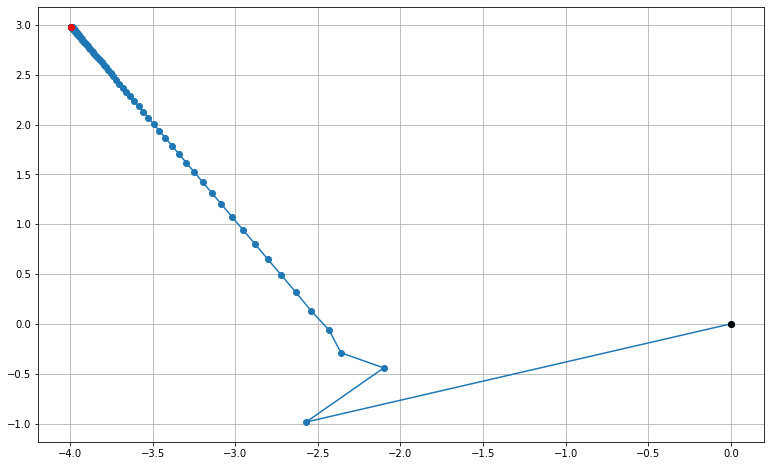

In [128]:
# plot the points
plt.figure(figsize=(13, 8))
plt.plot(phis[:,0], phis[:,1], '-o')

# overplot first and last points
plt.plot(phis[-1,0], phis[-1,1], '-or') 
plt.plot(phis[0,0], phis[0,1], '-ok')
plt.grid()
plt.show()

<span style="color:blue"> <i> Now make a scatter plot of the data and draw the best fit line found by the last iteration of gradient descent. The input data $x$ is entirely within the interval $[0,1]$.</i></span><br>

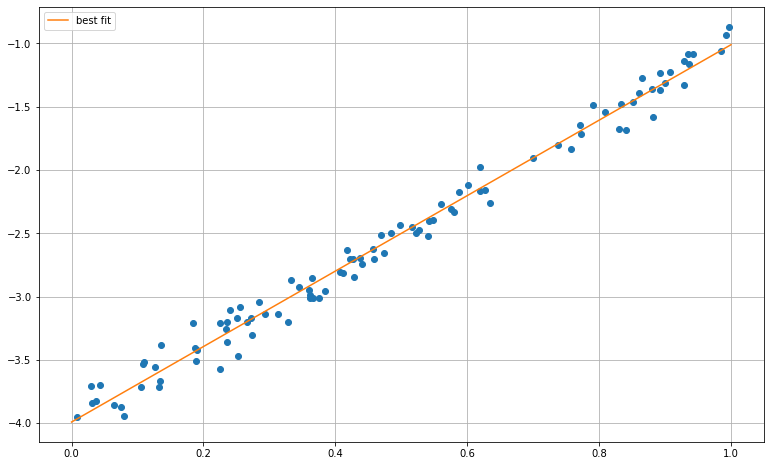

In [131]:
# Generate inputs and outputs using the best parameters
xp = np.linspace(0, 1, 1000)
yp = poly(phis[-1], xp)

# Plot points
plt.figure(figsize=(13, 8))
plt.plot(x, y, 'o')
plt.plot(xp, yp, label = 'best fit')
plt.legend()
plt.grid()
plt.show()

Now let's try doing this again with a new dataset that has more complexity, but still with input $x \in [0,1]$. This time, we'll try increasing the number of parameters.

<span style="color:blue"> <i> Load the new data and train neural networks for polynomials of order 1, 2, 3, and 4 ($m = 2,3,4,$ and $5$ terms, don't forget the constant term). Increase the number of iterations to 10000 (this will take a few seconds to run but it helps to train the more complicated networks). Then plot the training data and the polynomials of these orders. Finally, compute and print the empirical risk for each model on the training data. </i></span><br>

In [132]:
# Load the data
data = np.loadtxt("./Part4_data.dat")
x2 = data[2,:]
y2 = data[3,:]

In [133]:
# Define inputs the gradient descent function
# Hint: phi arrays are different sizes for each polynomial order,
# you can treat them all as the highest order, but with higher coefficients zero
dimarr = np.array([2,3,4,5])
maxdim = 5
lam = 0.5
delta = 1e-4
numiter = 10000
phisarr = np.zeros([4,maxdim,numiter+1])

# Run gradient descent for each network (polynomial order)
for i in range(4): 
    dim = dimarr[i]
    phi0 = np.zeros(int(dim))
    phis = gradient_descent(lambda phi: risk(phi, x2, y2), phi0, lam, delta, numiter) 
    phisarr[i,:dim] = np.transpose(phis)
    
# Extract best fit parameters for each network (polynomial order)
fit_phisarr = phisarr[:,:,-1]

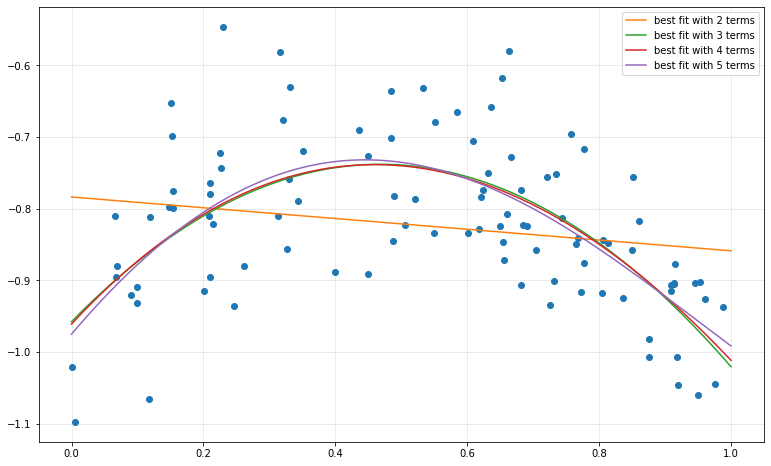

In [134]:
# Plot data and labels in a scatterplot
plt.figure(figsize=(13, 8))
plt.plot(x2, y2, 'o')

# Plot best fits for each polyomial order
xp = np.linspace(0, 1, 1000)
for i in range(4):
    yp_fit = poly(fit_phisarr[i], xp)
    plt.plot(xp, yp_fit, label = 'best fit with ' + str(dimarr[i]) + ' terms')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [135]:
# Compute and print risk for each model on the training data
risks = np.zeros(4)
for i in range(4):
    dim = dimarr[i]
    risks[i] = risk(fit_phisarr[i], x2, y2)
    print('risk on training data for ' + str(dim) + ' terms: ' + str(risks[i]))

risk on training data for 2 terms: 0.01229935500445878
risk on training data for 3 terms: 0.007499273168796524
risk on training data for 4 terms: 0.007456441556646939
risk on training data for 5 terms: 0.007419102474176251


If we have too few parameters in your network, we may not be able to correctly capture the complexity and diversity of the data, and this will lead to inaccurate predictions. But too many parameters can also be problematic. In many cases, the actual data that you might want to predict with your neural network might have a broader scope than the training data. Because of this, we want to be sure not to overfit our data with a model with too many parameters. If we have too many parameters, we will fit more than the underlying signal; we will also fit the noise. This will lead to a poor fit to testing data.

Here we are working with an expanded set of testing data, which is in the expanded interval $[0, 2]$.

<span style="color:blue"> <i> Load the new testing data (given) and plot it with the trained polynomials from the previous part in the expanded interval. Then compute and print the empirical risk for each model on the testing data. </i></span><br>

In [136]:
# Load the data
data = np.loadtxt("./Part4_data.dat")
x3 = data[4,:]
y3 = data[5,:]

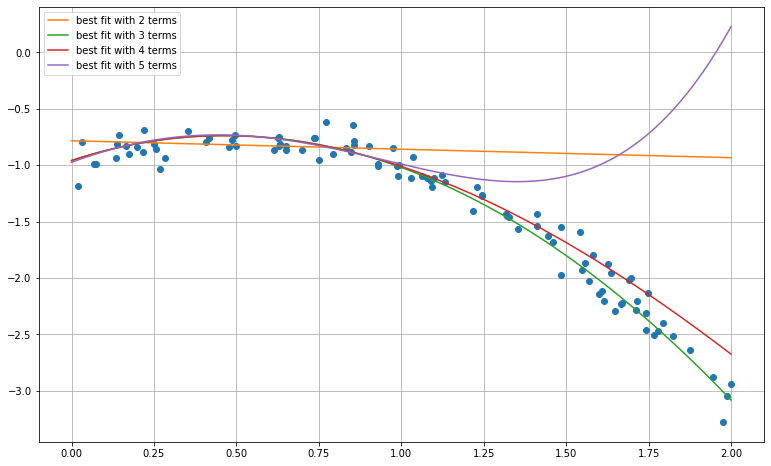

In [138]:
# Plot data and labels in a scatterplot
plt.figure(figsize=(13, 8))
plt.plot(x3, y3, 'o')

# Plot best fits for each polyomial order over the full interval [0, 2]
xp = np.linspace(0, 2, 1000)
for i in range(4):
    yp_fit =  poly(fit_phisarr[i], xp)
    plt.plot(xp, yp_fit, label = 'best fit with ' + str(dimarr[i]) + ' terms')
plt.legend()
plt.grid()
plt.show()

In [141]:
# Compute and print risk for each model on the testing data
risks = np.zeros(4)
for i in range(4):
    dim = dimarr[i]
    risks[i] =  risk(fit_phisarr[i], x3, y3)
    print('risk on testing data for ' + str(dim) + ' terms: ' + str(risks[i]))

risk on testing data for 2 terms: 0.6568373734794162
risk on testing data for 3 terms: 0.01270299283307805
risk on testing data for 4 terms: 0.025488083990060667
risk on testing data for 5 terms: 0.9077035978143723


<span style="color:blue"> <i> Which neural network best predicts the labels for the testing data? </i></span><br>

The Quadratic $(m=3)$ model.

***